# New Project Testbench


Project Sturcture
- Reproduce Lia's work -> code at...
- Structurize e.g.
  - query
  - reformatting
  - saving
  - merging
  - expand

## Lia's work

### open questions
- is the way we get to the radius right?
    - e.g. should in addition the distance be taken into account? 50 as at 50 pc is about 0.7pc (150kAU)
    - starcat vs hpic radius, where does the difference come from?
    - should we stack the catalogs first before determining the radius?
- save plots and show them to lia

In [8]:
from utils.io import load
[HPIC_StarCat,starcat5_not_in_hpic,pre_merge_hpic,pre_merge_starcat] = load(["HPIC_StarCat","starcat5_not_in_hpic","pre_merge_hpic","pre_merge_starcat"],location="../../../../additional_data/")
float_colnames = ["plx_value", "mag_i_value", "mag_j_value",
                      "dist_st_value",
                      "teff_st_value", "radius_st_value", "mass_st_value",
                      "sep_ang_value"]

FileNotFoundError: [Errno 2] No such file or directory: '../../../../additional_data/pre_merge_starcat.xml'

### Refactored code

hm, looks like the stars in starcat5 that are not in HPIC are quite a lot (15'000) and also from spectral types that we did not expect (B to G as well) -> ask lia about it in the next meeting. first make some more plots
potential reasons
- hpic excluded object for some unknown reason
- matching does not work as it should and object is present in hpic
    - identifier changed -> should get covered by position match
    - coordinates not of same era -> should only be few years appart

In [1]:
import catalog.starcat5_merger.merger as merger
import importlib

In [11]:
importlib.reload(merger)

<module 'catalog.starcat5_merger.merger' from '/home/franziska/PycharmProjects/life_td/data_generation/life_td_data_generation/catalog/starcat5_merger/merger.py'>

radius:  103.43301245378981


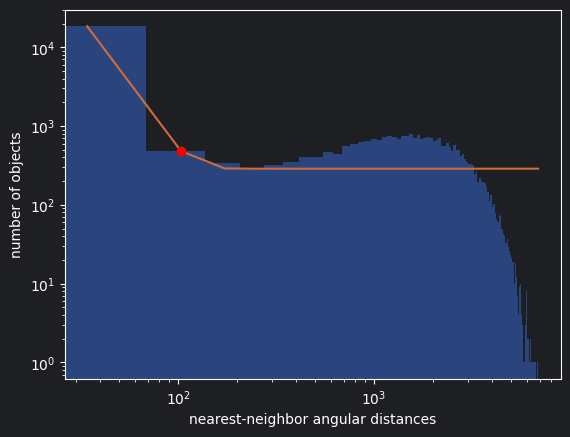

 in hpic 
  main_id        coo_ra        coo_dec   
                 deg            deg     
---------- --------------- -------------
LP  137-54 252.89855562033 51.6324558137
not in hpic 
 main_id coo_ra coo_dec
         deg     deg  
------- ------ -------
        temp_main_id            temp_coo_ra     ... stableHZ ecliptic_pm45deg
                                    deg         ...                          
---------------------------- ------------------ ... -------- ----------------
               TIC 459832522         213.915338 ...       --               --
               TIC 245873777          68.980213 ...       --               --
               TIC 272314138         187.791407 ...       --               --
               TIC 322899250         101.286998 ...       --               --
               TIC 368326352          79.172437 ...       --               --
               TIC 471011144         219.903981 ...       --               --
               TIC 280310048         114

In [12]:
catalog, pre_merge_starcat, starcat5, pre_merge_hpic, float_colnames, starcat5_in_hpic = merger.hpic_merger()
# still something going wrong, LP  137-54 should be in the "is in hpic" sample not other.

['temp_main_id', 'temp_coo_ra', 'temp_coo_dec', 'temp_sptype_string', 'temp_plx_value', 'temp_dist_st_value', 'coo_gal_l', 'coo_gal_b', 'temp_teff_st_value', 'temp_teff_ref', 'temp_mass_st_value', 'temp_mass_ref', 'temp_radius_st_value', 'temp_radius_ref', 'temp_binary_flag', 'binary_ref', 'temp_mag_i_value', 'temp_mag_j_value', 'class_lum', 'class_temp', 'parent_main_id', 'temp_sep_ang_value', 'unresolved_binaries', 'ms_temp_class', 'ms_lum_class', 'mass_flag', 'higher_order_multiples', 'single_parent', 'trivial_binaries', 'sep_flag', 'sep_phys_value', 'requirement_flag', 'suitable_companions', 'stableHZ', 'ecliptic_pm45deg']
        temp_main_id            temp_coo_ra     ... stableHZ ecliptic_pm45deg
                                    deg         ...                          
---------------------------- ------------------ ... -------- ----------------
Gaia DR3 5536411345052989184 113.02422391276501 ...                     False
            UCAC4 324-100764 257.70400202398287 ...  

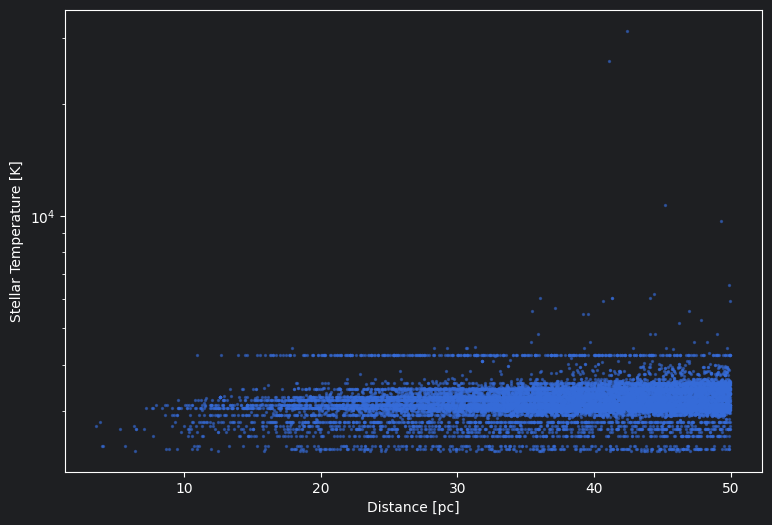

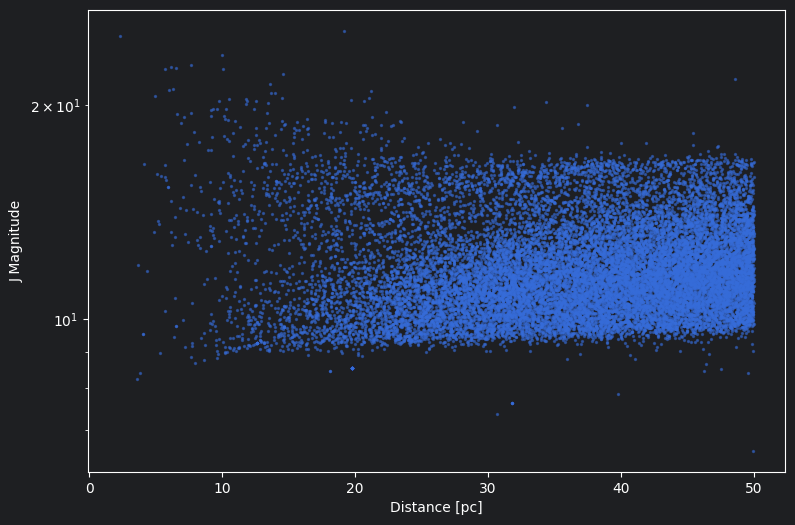

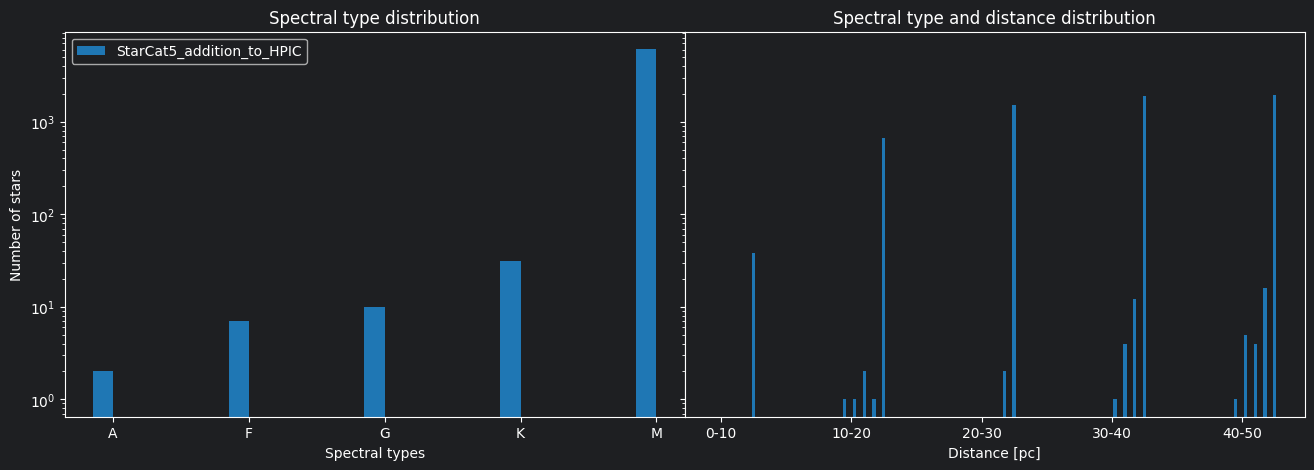

        temp_main_id            temp_coo_ra     ... stableHZ ecliptic_pm45deg
                                    deg         ...                          
---------------------------- ------------------ ... -------- ----------------
Gaia DR3 5536411345052989184 113.02422391276501 ...                     False
            UCAC4 324-100764 257.70400202398287 ...                      True
                  LP  440-13    215.68085465661 ...                      True
Gaia DR3 5876213901845135488 228.40549924602038 ...                      True
Gaia DR3 5937772809085981568 250.97912242932495 ...                      True
     2MASS J15531086+6235447  238.2952662336612 ...                     False
                  LP  801-14 222.54971100010997 ...                      True
Gaia DR3 5998630021747026560 241.45753527587084 ...                      True
Gaia DR3 5898283058681727872 220.88219899071748 ...                      True
                         ...                ... ...      ...    

In [6]:
print(pre_merge_starcat.colnames)
print(pre_merge_starcat)
merger.analysis_starcat5_not_in_hpic(pre_merge_starcat) # wait, that is supposed to be stuff that is in hpic...

In [10]:
merger.merger_analysis(pre_merge_hpic, pre_merge_starcat,HPIC_StarCat,float_colnames)

NameError: name 'pre_merge_starcat' is not defined

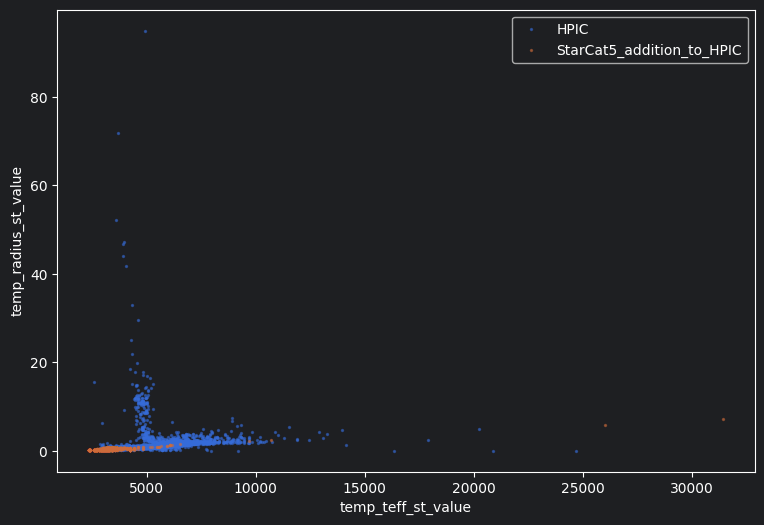

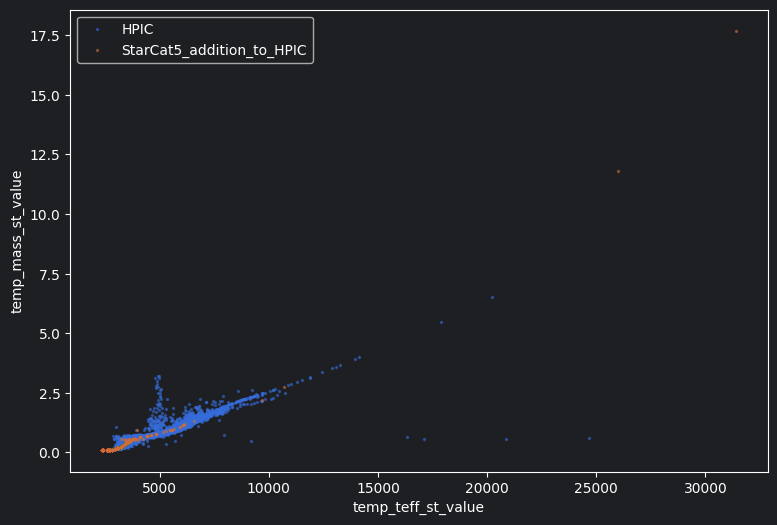

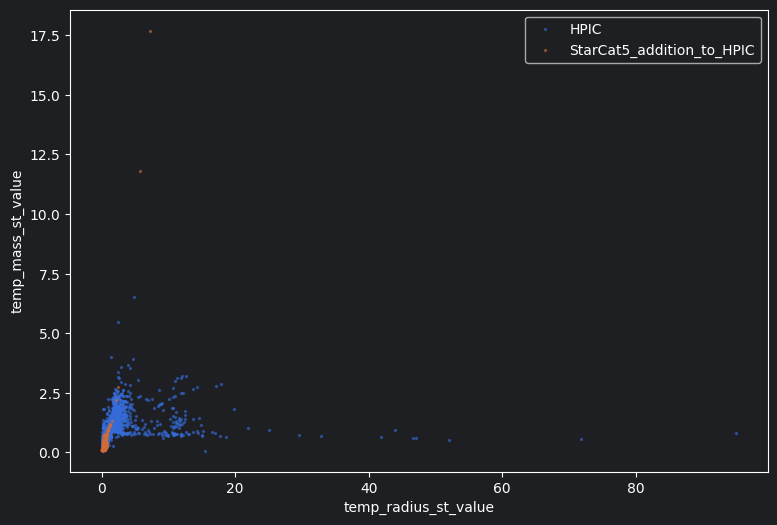

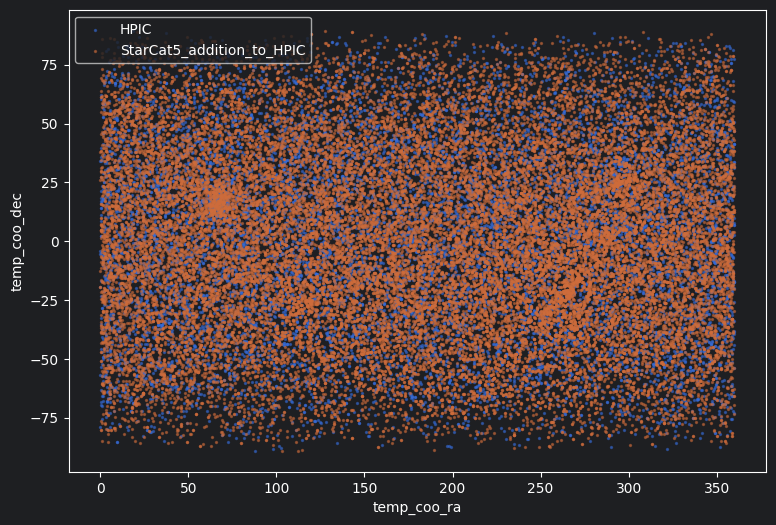

In [10]:
importlib.reload(merger)

merger.plot_para_vs_para(pre_merge_hpic,pre_merge_starcat)

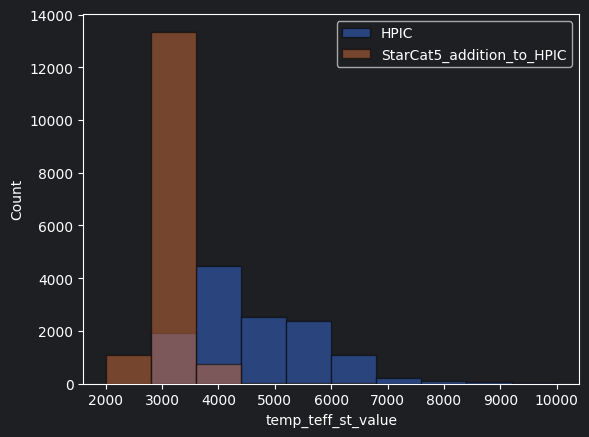

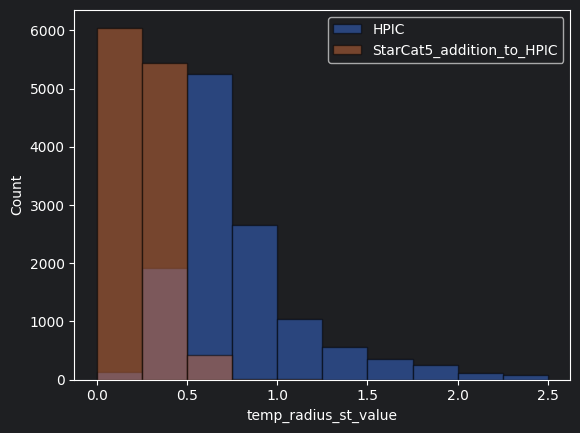

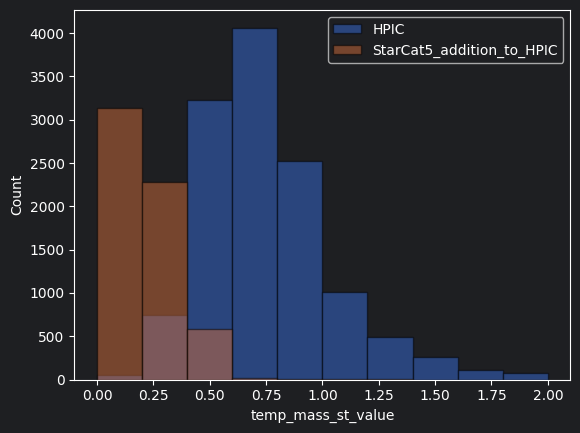

In [11]:
def hist_plot(pre_merge_hpic,masked_starcat5):
    alf = 0.5
    edgecol = "black"
    for col, range in zip(["temp_teff_st_value","temp_radius_st_value","temp_mass_st_value"],\
            [[2000,10000], [0,2.5], [0,2]]):
        plt.figure()
        plt.hist(pre_merge_hpic[col], alpha = alf, edgecolor = edgecol,
                 label = "HPIC", range = range)
        plt.hist(masked_starcat5[col], alpha = alf, edgecolor = edgecol,
                 label = "StarCat5_addition_to_HPIC", range = range)
        plt.legend()
        plt.xlabel(col)
        plt.ylabel("Count")
        plt.show()
    return

hist_plot(pre_merge_hpic,pre_merge_starcat)

In [12]:
import numpy as np


def spec_dist_plot(pre_merge_hpic):
    x = ["M0","M1","M2","M3","M4","M5","M6","M7","M8","M9"]
    spectype = np.array(pre_merge_hpic['temp_sptype_string'])
    for i in range(len(spectype)):
        spectype[i]=spectype[i][0:2]
    plt.figure()
    plt.hist(spectype)
    plt.xlabel("Spectral Subclass")
    plt.ylabel("Number of stars")
    plt.show()
    return

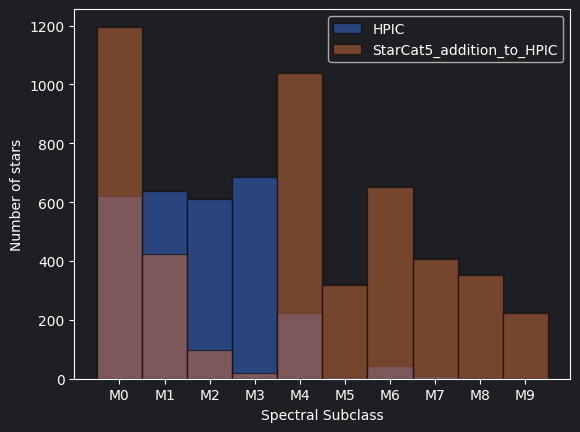

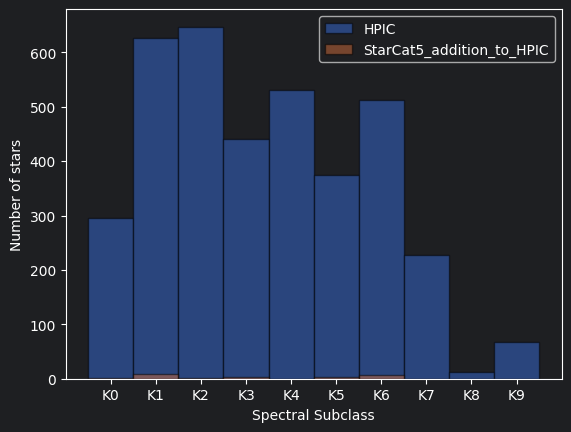

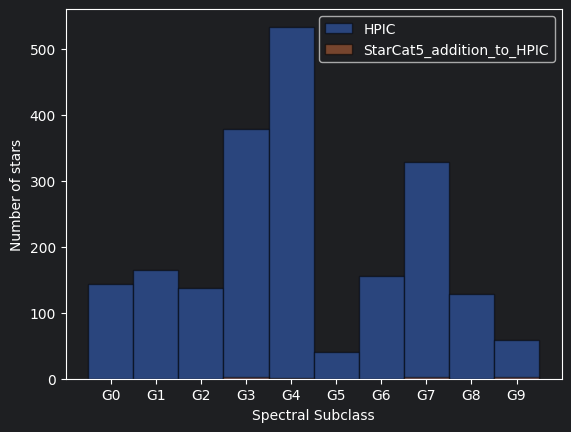

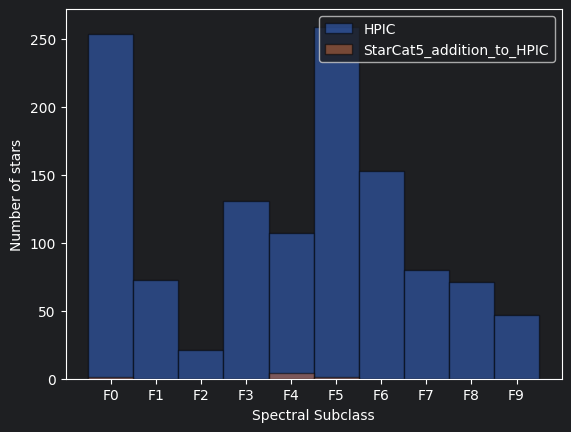

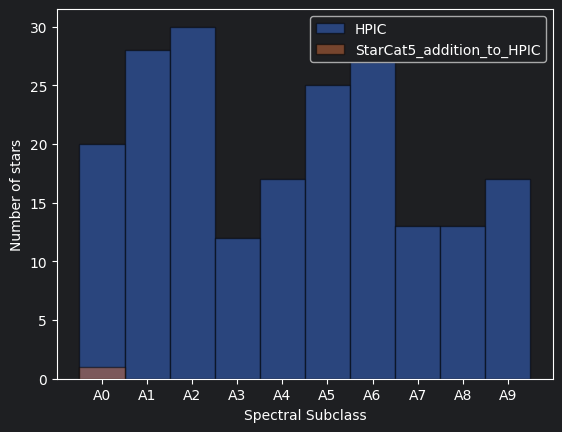

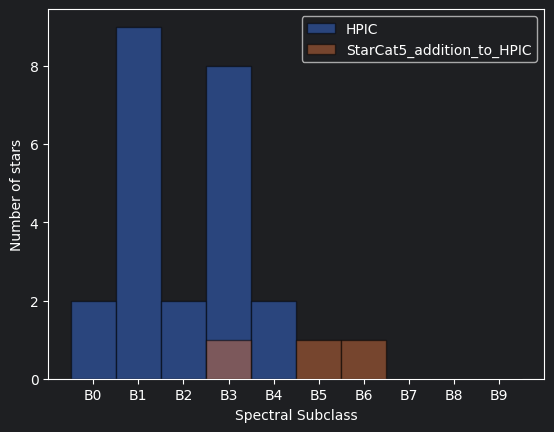

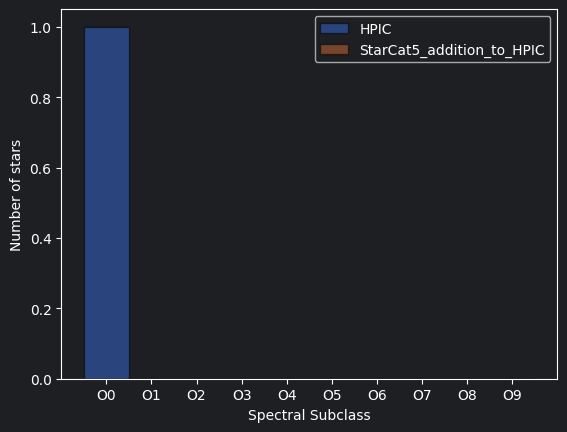

In [13]:
import numpy as np
import matplotlib.pyplot as plt



merger.spec_dist_plot([pre_merge_hpic, pre_merge_starcat],
               ["M0", "M1", "M2", "M3", "M4", "M5", "M6", "M7", "M8", "M9"])

merger.spec_dist_plot([pre_merge_hpic, pre_merge_starcat],
               ["K0", "K1", "K2", "K3", "K4", "K5", "K6", "K7", "K8", "K9"])

merger.spec_dist_plot([pre_merge_hpic, pre_merge_starcat],
               ["G0", "G1", "G2", "G3", "G4", "G5", "G6", "G7", "G8", "G9"])

merger.spec_dist_plot([pre_merge_hpic, pre_merge_starcat],
               ["F0", "F1", "F2", "F3", "F4", "F5", "F6", "F7", "F8", "F9"])

merger.spec_dist_plot([pre_merge_hpic, pre_merge_starcat],
               ["A0", "A1", "A2", "A3", "A4", "A5", "A6", "A7", "A8", "A9"])

merger.spec_dist_plot([pre_merge_hpic, pre_merge_starcat],
               ["B0", "B1", "B2", "B3", "B4", "B5", "B6", "B7", "B8", "B9"])

merger.spec_dist_plot([pre_merge_hpic, pre_merge_starcat],
               ["O0", "O1", "O2", "O3", "O4", "O5", "O6", "O7", "O8", "O9"])


In [3]:
print(catalog.colnames)

['temp_main_id', 'temp_coo_ra', 'temp_coo_dec', 'ra_J2016', 'dec_J2016', 'tic_id', 'gaia_dr2_id', 'gaia_dr3_id', 'hip_name', 'tm_name', 'tyc_name', 'wds_designation', 'simbad_name', 'source_list_fl', 'sy_pmra', 'sy_pmraerr', 'sy_pmdec', 'sy_pmdecerr', 'sy_pmsrc', 'sy_pm_reflink', 'sy_ujmag', 'sy_ujmagerr', 'sy_ujmagsrc', 'sy_ujmag_reflink', 'sy_bmag', 'sy_bmagerr', 'sy_bmagsrc', 'sy_bmag_reflink', 'sy_vmag', 'sy_vmagerr', 'sy_vmagsrc', 'sy_vmag_reflink', 'sy_rcmag', 'sy_rcmagerr', 'sy_rcmagsrc', 'sy_rcmag_reflink', 'temp_mag_i_value', 'sy_icmagerr', 'sy_icmagsrc', 'sy_icmag_reflink', 'temp_mag_j_value', 'sy_jmagerr', 'sy_jmagsrc', 'sy_jmag_reflink', 'sy_hmag', 'sy_hmagerr', 'sy_hmagsrc', 'sy_hmag_reflink', 'sy_kmag', 'sy_kmagmerr', 'sy_kmagsrc', 'sy_kmag_reflink', 'sy_tmag', 'sy_tmagerr', 'sy_gaiamag', 'sy_gaiamagerr', 'sy_gaiamagsrc', 'sy_gaiamag_reflink', 'sy_bpmag', 'sy_bpmagerr', 'sy_rpmag', 'sy_rpmagerr', 'temp_plx_value', 'sy_plxerr', 'sy_plxsrc', 'sy_plx_reflink', 'temp_dist_st_

In [8]:
#* eta UMa is a B star that is flagged as not being in HPIC, foung gaia dr3 id and searching in HPIC starcat merger

import numpy as np
print(catalog['gaia_dr3_id'])
print(catalog['simbad_name','gaia_dr3_id','temp_coo_ra', 'temp_coo_dec'][np.where(catalog['gaia_dr3_id'] == "1510374147844219904")])
# found object that is said to not be in HPIC but actually is
# check if main_id starcat5_masked matches simbad_name catalog # they do -> made test -> found out need to take inverse of mask. run stuff again but got same issue
# check if coordinates matche
# check if starcat5_masked is correctly assigned and not an alias of catalog...

gaia_dr3_id
-----------
       null
       null
       null
       null
       null
       null
       null
       null
       null
       null
        ...
           
           
           
           
           
           
           
           
           
           
Length = 28819 rows
simbad_name     gaia_dr3_id       temp_coo_ra    temp_coo_dec 
                                      deg            deg      
----------- ------------------- --------------- --------------
  * eta UMa 1510374147844219904 206.88435898896 49.31320798716


In [19]:
# "HPIC_StarCat","starcat5_not_in_hpic","pre_merge_hpic"
import numpy as np

hpic_name = pre_merge_hpic['simbad_name'][np.where(pre_merge_hpic['tyc_name'] == "1313-276-1")]
starcat_name = pre_merge_starcat['temp_main_id'][np.where(pre_merge_starcat['temp_main_id'] == "TYC 1313-276-1")]
print(hpic_name)
print(starcat_name, hpic_name == starcat_name)
# so names are identical meaning match function might have an issue -> create a unit test

# not found, try to find it in coordinates. though it is strange that gdr3 not found
# tic 151356685

simbad_name
-----------
 temp_main_id 
--------------
TYC 1313-276-1 []


In [20]:
type(pre_merge_hpic['tyc_name'][0])

str

In [34]:
print(pre_merge_hpic['simbad_name','temp_coo_ra','temp_coo_dec'][np.where(pre_merge_hpic['simbad_name'] == "LP  137-54")])
print(starcat5_not_in_hpic['main_id','coo_ra','coo_dec'][np.where(starcat5_not_in_hpic['main_id'] == "LP  137-54")])


simbad_name   temp_coo_ra    temp_coo_dec 
----------- --------------- --------------
 LP  137-54 252.89855630184 51.63245588655
 main_id        coo_ra        coo_dec   
                 deg            deg     
---------- --------------- -------------
LP  137-54 252.89855562033 51.6324558137


## Input
try to query different archives outside of db context

In [3]:
from provider.utils import query

### Gaia

Notes: I could technically structurize it more (input parameters, output parameters,...) but don't think is useful at this point as not all sources will be via adql. better get list first, then write function for structuring.

In [1]:
adql_query = """
    SELECT s.source_id ,p.mass_flame, p.radius_flame,
        p.teff_gspphot, p.teff_gspspec, m.nss_solution_type, p.age_flame,
        p.teff_gspspec_lower, p.teff_gspspec_upper, p.flags_gspspec
    FROM gaiadr3.gaia_source as s
        JOIN gaiadr3.astrophysical_parameters as p ON s.source_id=p.source_id
            LEFT JOIN gaiadr3.nss_two_body_orbit as m ON s.source_id=m.source_id
    WHERE s.parallax >=30."""

gaia_helptab = query("https://gea.esac.esa.int/tap-server/tap", adql_query)

Service is UP and running.


In [2]:
print(gaia_helptab)

     source_id      mass_flame ...               flags_gspspec              
                     solMass   ...                                          
------------------- ---------- ... -----------------------------------------
    769456276704128         -- ...                                          
  56252256123908096         -- ...                                          
  60186343087140096  0.7181468 ... 00000000000001110009900001000999999999995
  73326018139806592         -- ... 00100111000009999999999999999999999999999
  78649033103283584         -- ...                                          
  98092934167683072         -- ...                                          
 115311458058061440  0.8797081 ... 00000000000001010000000109900990099999995
 115851902384016128         -- ...                                          
 126342377182577408         -- ...                                          
                ...        ... ...                                       ...

### HWO

In [ ]:
# spores see utils.analysis.create_other_catalogs
# same for HPIC
# so far both accessed via downloaded csv file. as they are not supposed to change often, I could keep it that way
# spores can be downloaded at https://sites.google.com/berkeley.edu/spores-hwo/science
# old saving location is Nebenproject/life_cat/data

## Reformatting

In [ ]:
# input table
# changes in column name
# changes in data e.g. unit


## Saving

In [ ]:
# input table (astropy? or pandas)
# output structure, so far

save(
    [table],
    ["name"],
    location="...",
)